In [72]:
import pandas as pd 
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import plotly.express as px

In [73]:
try:
    df=sns.load_dataset('penguins')
    print('Dataset Loaded Successfully')
except:
    print('Dataset Not Found')

Dataset Loaded Successfully


In [74]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [75]:
df.isnull().sum().sort_values(ascending=False)

sex                  11
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
species               0
island                0
dtype: int64

In [76]:
df.select_dtypes(include=['int','float'])

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0
...,...,...,...,...
339,NaN,NaN,NaN,NaN
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


In [77]:
px.area(df,x='body_mass_g')

In [78]:
px.box(df,x='flipper_length_mm')

In [79]:
px.box(df,x='bill_length_mm')

In [80]:
px.violin(df,x='bill_depth_mm')

In [81]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer,make_column_selector as selector
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder,StandardScaler,RobustScaler

num=Pipeline([
    ('imputer',KNNImputer(n_neighbors=5)),
    ('scaler',StandardScaler())
])

cat=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('enocoder',OrdinalEncoder())
])
preprocessor=ColumnTransformer([
    ('nums',num,selector(dtype_include='number')),
    ('cats',cat,selector(dtype_include=['object','category']))
])

preprocessor

,transformers,"[('nums', ...), ('cats', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,n_neighbors,5
,weights,'uniform'


In [82]:
model.fit(X_train,y_train)
y_pred=model.predict(X_test)



In [83]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

(array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5]),
 <BarContainer object of 10 artists>)

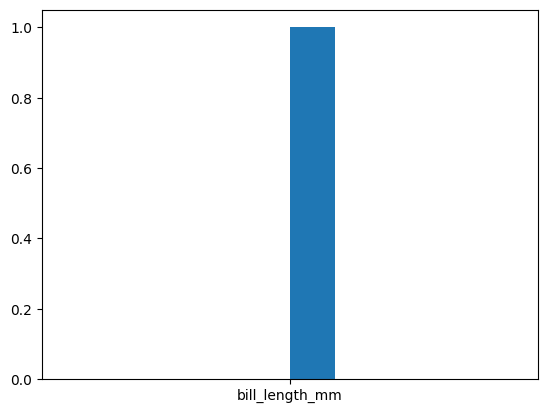

In [84]:
plt.hist(x='bill_length_mm')

In [85]:
px.box(df,x='bill_depth_mm')

In [86]:
px.box(df,x='body_mass_g')

In [87]:
px.violin(df,x='sex')

In [88]:
px.violin(df,x='species')

(array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5]),
 <BarContainer object of 10 artists>)

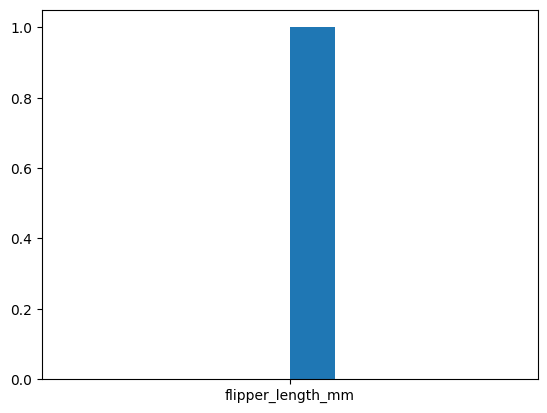

In [89]:
plt.hist(x='flipper_length_mm')

In [90]:
px.box(df,x='island')

In [91]:
from sklearn.model_selection import  train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.naive_bayes import GaussianNB
X=df.drop('species',axis=1)
y=df['species']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=Pipeline([
    ('preprocessing',preprocessor),
    ('model',GaussianNB())
])

model

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nums', ...), ('cats', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [92]:
from sklearn.metrics import classification_report,confusion_matrix,precision_score,recall_score,f1_score,accuracy_score

print('Accuracy',accuracy_score(y_test,y_pred))
print('Recall Score',recall_score(y_test,y_pred,average='weighted'))
print('f1 score',f1_score(y_test,y_pred,average='weighted'))
print('precision score',precision_score(y_test,y_pred,average='weighted'))
print('Confusion Matrix',confusion_matrix(y_test,y_pred))
print('\nClassification Report\n',classification_report(y_test,y_pred))

Accuracy 0.855072463768116
Recall Score 0.855072463768116
f1 score 0.8561377805666608
precision score 0.9026877470355732
Confusion Matrix [[22  9  1]
 [ 0 16  0]
 [ 0  0 21]]

Classification Report
               precision    recall  f1-score   support

      Adelie       1.00      0.69      0.81        32
   Chinstrap       0.64      1.00      0.78        16
      Gentoo       0.95      1.00      0.98        21

    accuracy                           0.86        69
   macro avg       0.86      0.90      0.86        69
weighted avg       0.90      0.86      0.86        69

